In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

env = gym.make('FrozenLake-v1', is_slippery=False)

# Get observation and action space sizes
n_observations = env.observation_space.n
n_actions = env.action_space.n

print(f"Observation space size: {n_observations}")
print(f"Action space size: {n_actions}")

Observation space size: 16
Action space size: 4


In [3]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

learning_rate = 0.9 # Alpha
discount_factor = 0.9 # Gamma
epsilon = 1.0 # Epsilon
epsilon_decay_rate = 0.0001
min_epsilon = 0.1
num_episodes = 20000

In [4]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_observations, n_actions))


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def choose_action(state, epsilon, Q):
    if np.random.rand() < epsilon:
        return env.action_space.sample() # Explore
    else:
        return np.argmax(Q[state, :]) # Exploit

In [5]:
# -------------------------------------------------
# Q-Learning Training
# -------------------------------------------------

episode_rewards = []

for episode in range(num_episodes):
    state, info = env.reset()
    done = False
    truncated = False
    total_episode_reward = 0

    while not done and not truncated:
        action = choose_action(state, epsilon, Q)
        new_state, reward, done, truncated, info = env.step(action)

        # Q-learning formula
        Q[state, action] = Q[state, action] + learning_rate * (
            reward + discount_factor * np.max(Q[new_state, :]) - Q[state, action]
        )

        state = new_state
        total_episode_reward += reward

    epsilon = max(min_epsilon, epsilon - epsilon_decay_rate) # Decay epsilon
    episode_rewards.append(total_episode_reward)

# Extract learned policy and state values
learned_policy = np.argmax(Q, axis=1)
state_values = np.max(Q, axis=1)

In [6]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [7]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.531 0.59  0.59  0.531]
 [0.531 0.    0.656 0.59 ]
 [0.59  0.729 0.59  0.656]
 [0.656 0.    0.59  0.59 ]
 [0.59  0.656 0.    0.531]
 [0.    0.    0.    0.   ]
 [0.    0.81  0.    0.656]
 [0.    0.    0.    0.   ]
 [0.656 0.    0.729 0.59 ]
 [0.656 0.81  0.81  0.   ]
 [0.729 0.9   0.    0.729]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.81  0.9   0.729]
 [0.81  0.9   1.    0.81 ]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.59  0.656 0.729 0.656]
 [0.656 0.    0.81  0.   ]
 [0.729 0.81  0.9   0.   ]
 [0.    0.9   1.    0.   ]]

Learned Policy:
[['D' 'R' 'D' 'L']
 ['D' 'L' 'D' 'L']
 ['R' 'D' 'D' 'L']
 ['L' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 0.926


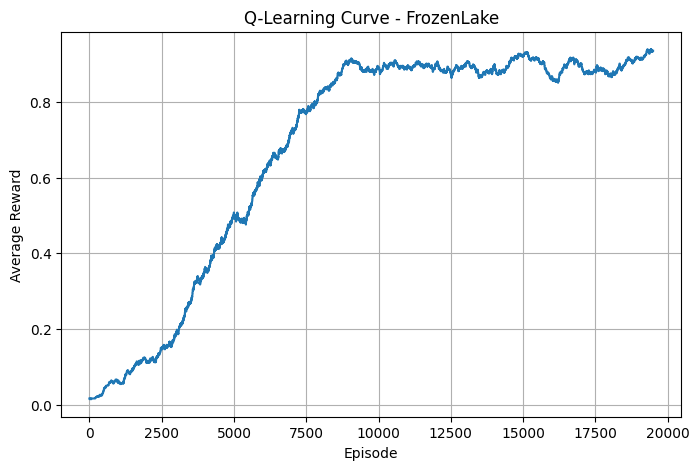

In [8]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()